In [1]:
import json
import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy


%load_ext autoreload
%autoreload 2
%aimport connectivity

allowed_ids = ["EL019", "EL020", "EL021", "EL022", "EL026", "EL027", "EL028", "EL011", "EL012", "EL013", "EL014", "EL015", "EL016"]

SOURCE = "output" # "publish_data/paper"
EXTENDED_MEASURES_FILE = f"../{SOURCE}/significant_responses/extended_measures_lf.json"
RESPONSES_FILE = f"../{SOURCE}/significant_responses/response_channels_lf.json"

In [2]:


from connectivity.load import parsed_list_to_numpy_array


extended_measures_df = pd.read_json(EXTENDED_MEASURES_FILE)
extended_measures_df = extended_measures_df[extended_measures_df["patient_id"].isin(allowed_ids)]
responses_df = pd.read_json(RESPONSES_FILE)

extended_measures_df = extended_measures_df.merge(right=responses_df[["patient_id", "stim_channel_name", "response_channel_name", "med_lls"]], how="left", on=["patient_id", "stim_channel_name", "response_channel_name"])

exploded = []
rows = []
measures = ["n1", "n2", "peak_to_peak", "root_mean_square"]
friendly_measure_names = {
    "ll": "Line-length",
    "n1": "N1",
    "n2": "N2",
    "peak_to_peak": "Peak-to-peak",
    "root_mean_square": "Root-mean-squared"
}


for i_row, df_row in extended_measures_df.iterrows():
    # for measure in measures:
    #     med_values = parsed_list_to_numpy_array(df_row[f"{measure}_med_values"]) # shape: (n_intensities, n_reps)
    #     for i_int, val in enumerate(med_values[1:]):
    #         exploded.append({
    #             "patient_id": df_row["patient_id"],
    #             "measure": measure,
    #             "value": val,
    #         })
    # # add ll
    # for i_int, val in enumerate(df_row["med_lls"][1:]):
    #     exploded.append({
    #         "patient_id": df_row["patient_id"],
    #         "measure": "ll",
    #         "value": val,
    #     })
    med_lls = parsed_list_to_numpy_array(df_row["med_lls"])
    for i_int in range(med_lls.shape[0] - 1):
        row = {
            "patient_id": df_row["patient_id"],
            "stim_channel_name": df_row["stim_channel_name"],
            "response_channel_name": df_row["response_channel_name"],
            "ll_med_values": med_lls[i_int + 1],

        }
        for measure in measures:
            med_values = parsed_list_to_numpy_array(df_row[f"{measure}_med_values"]) # shape: (n_intensities, n_reps)
            row[f"{measure}_med_values"] = med_values[i_int + 1]

        rows.append(row)
measure_df = pd.DataFrame(rows)



n=45452
n=45452
n=45452
n=45452


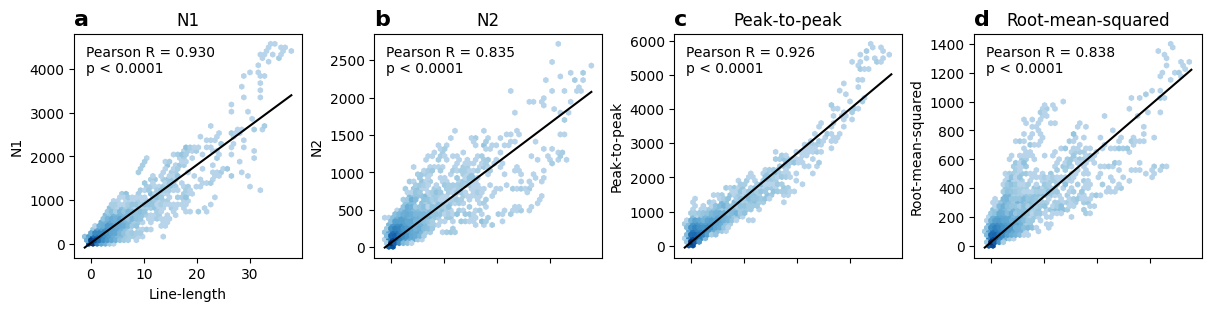

In [3]:
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.gridspec import GridSpec
import seaborn as sns
import scipy

def format_p(p):
    return "p < 0.0001" if p < 0.0001 else f"p = {p:.4f}"

fig = plt.figure(figsize=(12, 3), constrained_layout=True)
gs = GridSpec(1, 4, figure=fig)

panel_ids = ["a", "b", "c", "d"]

cmap = plt.get_cmap("Blues")
# keep only the darker 30–100 % range of the colormap
cmap_trunc = LinearSegmentedColormap.from_list(
    "Blues_trunc", cmap(np.linspace(0.3, 1.0, 256))
)

for i_measure, measure in enumerate(measures):
    ax = fig.add_subplot(gs[0, i_measure])

    print(f"n={len(measure_df["ll_med_values"])}")
    ax.hexbin(
        measure_df["ll_med_values"],
        measure_df[f"{measure}_med_values"],
        gridsize=50,
        cmap=cmap_trunc,
        norm=LogNorm(),     # log-scaled color
        mincnt=1
    )

    slope, intercept, r, p, stderr = scipy.stats.linregress(measure_df["ll_med_values"], measure_df[f"{measure}_med_values"])

    # regression line
    x_cont = np.linspace(measure_df["ll_med_values"].min(), measure_df["ll_med_values"].max(), 200)
    y_cont = slope * x_cont + intercept

    ax.plot(x_cont, y_cont, color="black")
    ax.set_title(panel_ids[i_measure], loc='left', fontsize=16, fontweight='bold')

    ax.annotate(f"Pearson R = {r:.3f}\n{format_p(p)}",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        ha="left",
        va="top")
    
    ax.set_title(friendly_measure_names[measure])
    ax.set_ylabel(f"{friendly_measure_names[measure]}")
    if i_measure == 0:
        ax.set_xlabel("Line-length")
    else:
        plt.setp(ax.get_xticklabels(), visible=False)

    # ax.scatter(
    #     measure_df["ll_med_values"],
    #     measure_df[f"{measure}_med_values"],
    #     s=5,    
    #     alpha=0.5,
    # )
    #sns.jointplot(data=measure_df, x="ll_med_values", y=f"{measure}_med_values", kind="hex", ax=ax)

plt.savefig("../output/figures/sfigure6.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../output/figures/sfigure6.svg", bbox_inches='tight', dpi=300)
plt.show()

